<a href="https://colab.research.google.com/github/cimolgoreng-cpu/HDHM_Exp01_Orthogonality_Validation/blob/main/HDHM_Exp01_Orthogonality_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def generate_hypervector(dim=10000):
    # Menghasilkan vektor acak berisi -1 atau 1
    return np.random.choice([-1, 1], size=dim)

# Mari kita buat dua objek data berbeda (Data Asli vs Decoy)
A = generate_hypervector()
B = generate_hypervector()

print(f"Vektor A dan B dengan dimensi {len(A)} telah tercipta.")

Vektor A dan B dengan dimensi 10000 telah tercipta.


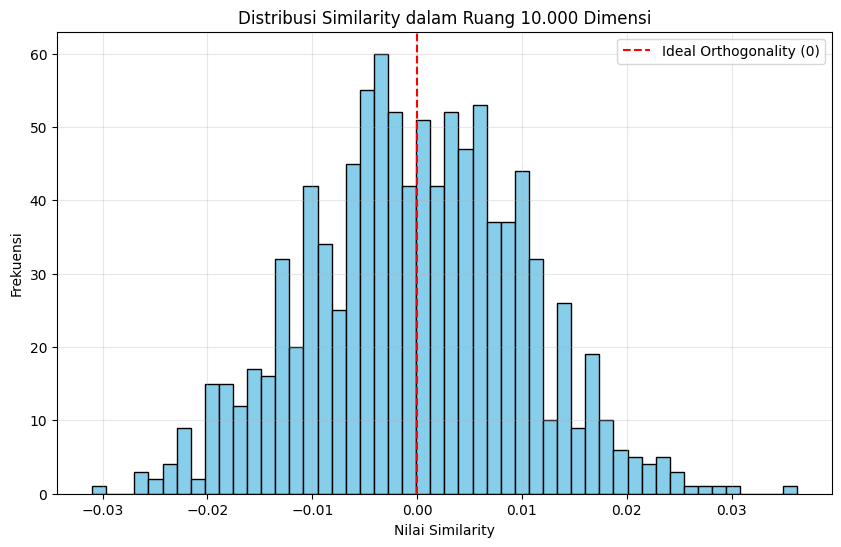

Rata-rata similarity dari 1.000 sampel: -0.000209
Kesimpulan: VALID


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Definisi Fungsi Dasar ---
def generate_hypervector(dim=10000):
    """Menghasilkan vektor bipolar acak {-1, 1}."""
    return np.random.choice([-1, 1], size=dim)

def compute_similarity(v1, v2):
    """Menghitung Cosine Similarity (Kedekatan antara dua vektor)."""
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

# --- 2. Inisialisasi Objek (The Mirror Objects) ---
# Kita buat Data Asli (A) dan satu sampel Decoy acak (B)
A = generate_hypervector()
B = generate_hypervector()

# --- 3. Pengujian Distribusi (Uji Massal) ---
# Untuk membuktikan hipotesis, kita tidak bisa hanya menguji dua vektor.
# Kita akan menguji 1.000 pasangan vektor acak untuk melihat persebarannya.
similarities = []
for _ in range(1000):
    v1 = generate_hypervector()
    v2 = generate_hypervector()
    similarities.append(compute_similarity(v1, v2))

# --- 4. Visualisasi Hasil ---
plt.figure(figsize=(10, 6))
plt.hist(similarities, bins=50, color='skyblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', label='Ideal Orthogonality (0)')
plt.title('Distribusi Similarity dalam Ruang 10.000 Dimensi')
plt.xlabel('Nilai Similarity')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- 5. Output Logika ---
mean_sim = np.mean(similarities)
print(f"Rata-rata similarity dari 1.000 sampel: {mean_sim:.6f}")
print(f"Kesimpulan: {'VALID' if abs(mean_sim) < 0.01 else 'INVALID'}")